# Predicting Student Test Scores

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQyAmIYqfHobCJSr5jicySW2chapPV8oB179g&s'>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

In [3]:
print(train.shape)
print(test.shape)

(630000, 13)
(270000, 12)


In [4]:
train.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [5]:
test.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [6]:
train.isnull().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [7]:
df = pd.concat([train, test], axis=0).reset_index(drop=True)

In [8]:
df.shape

(900000, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900000 entries, 0 to 899999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                900000 non-null  int64  
 1   age               900000 non-null  int64  
 2   gender            900000 non-null  object 
 3   course            900000 non-null  object 
 4   study_hours       900000 non-null  float64
 5   class_attendance  900000 non-null  float64
 6   internet_access   900000 non-null  object 
 7   sleep_hours       900000 non-null  float64
 8   sleep_quality     900000 non-null  object 
 9   study_method      900000 non-null  object 
 10  facility_rating   900000 non-null  object 
 11  exam_difficulty   900000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 89.3+ MB


In [10]:
df.isnull().sum()

id                       0
age                      0
gender                   0
course                   0
study_hours              0
class_attendance         0
internet_access          0
sleep_hours              0
sleep_quality            0
study_method             0
facility_rating          0
exam_difficulty          0
exam_score          270000
dtype: int64

In [11]:
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,900000.0,449999.500000,259807.765474,0.000,224999.75,449999.5,674999.25,899999.00
age,900000.0,20.545316,2.260301,17.000,19.00,21.0,23.00,24.00
study_hours,900000.0,4.002800,2.359238,0.080,1.98,4.0,6.05,7.91
class_attendance,900000.0,71.985836,17.425469,40.600,57.00,72.6,87.20,99.40
sleep_hours,900000.0,7.072552,1.745021,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


Text(0, 0.5, 'Exam Score')

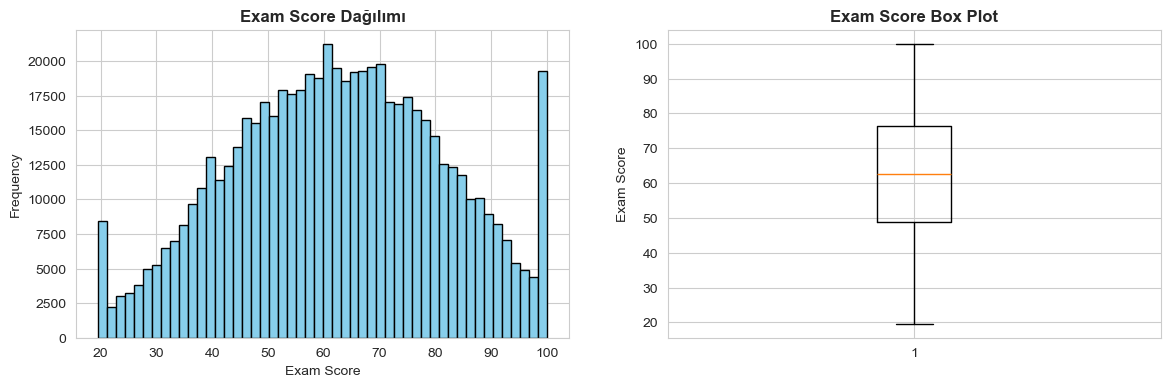

In [13]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.hist(df['exam_score'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title('Exam Score Dağılımı', fontsize=12, fontweight='bold')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(df['exam_score'].dropna())
plt.title('Exam Score Box Plot', fontsize=12, fontweight='bold')
plt.ylabel('Exam Score')

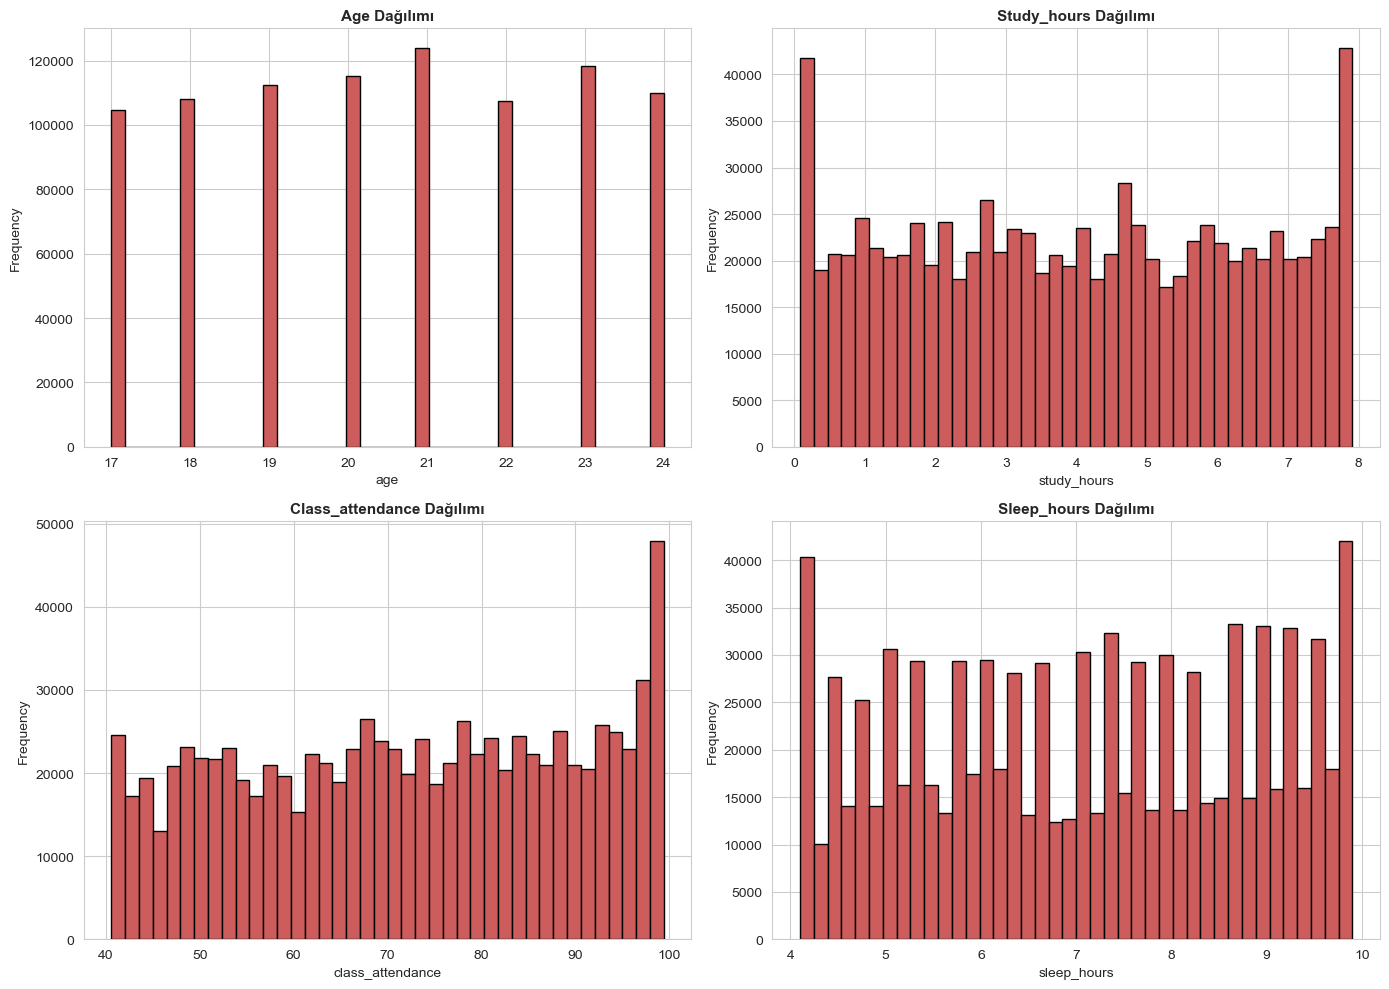

In [14]:
numeric_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

plt.figure(figsize=(14, 10))
for idx, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, idx)
    plt.hist(df[col], bins=40, color='IndianRed', edgecolor='black')
    plt.title(f'{col.capitalize()} Dağılımı', fontsize=11, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

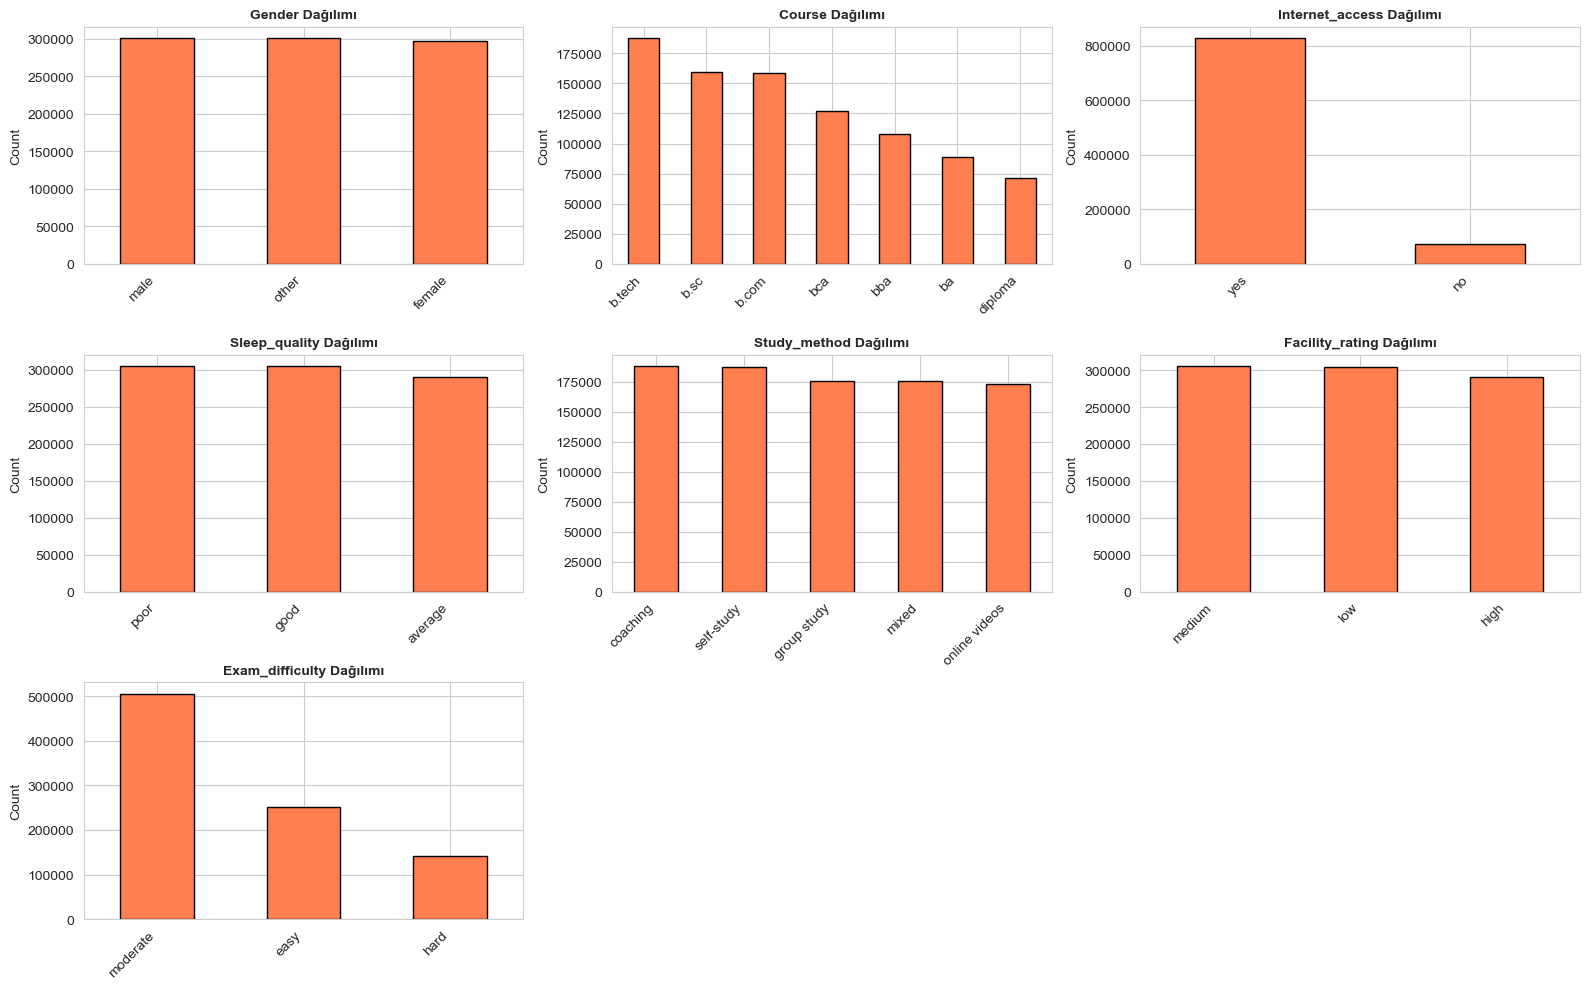

In [15]:
categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

plt.figure(figsize=(16, 10))
for idx, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, idx)
    df[col].value_counts().plot(kind='bar', color='coral', edgecolor='black')
    plt.title(f'{col.capitalize()} Dağılımı', fontsize=10, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

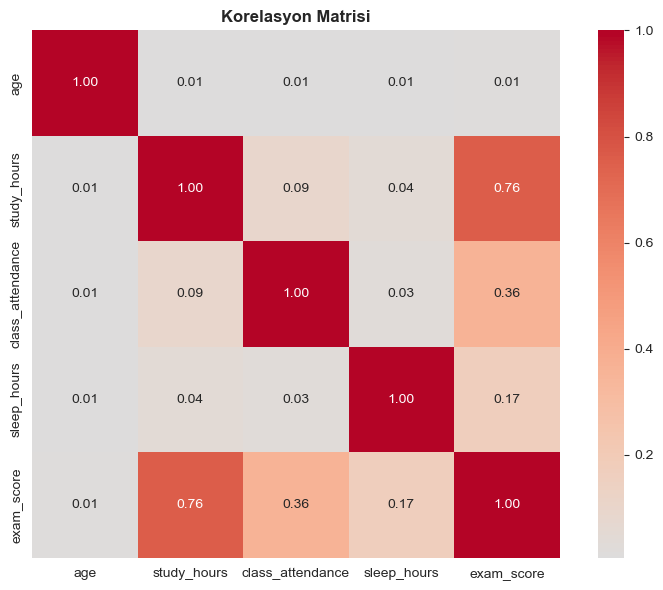

In [16]:
#Correlation Matrix
numeric_with_target = numeric_cols + ['exam_score']
correlation_matrix = train[numeric_with_target].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Korelasyon Matrisi', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900000 entries, 0 to 899999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                900000 non-null  int64  
 1   age               900000 non-null  int64  
 2   gender            900000 non-null  object 
 3   course            900000 non-null  object 
 4   study_hours       900000 non-null  float64
 5   class_attendance  900000 non-null  float64
 6   internet_access   900000 non-null  object 
 7   sleep_hours       900000 non-null  float64
 8   sleep_quality     900000 non-null  object 
 9   study_method      900000 non-null  object 
 10  facility_rating   900000 non-null  object 
 11  exam_difficulty   900000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 89.3+ MB


In [18]:
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [19]:
df.gender.value_counts()

gender
male      301275
other     301208
female    297517
Name: count, dtype: int64

In [20]:
# Feature Engineering

In [21]:
#Internet_access
df['internet_access'] = (df['internet_access'] == 'yes').astype(int)

#sleep_quality
sleep_quality = {'poor': 1, 'average': 2, 'good': 3}
df['sleep_quality'] = df['sleep_quality'].map(sleep_quality)

#facility_rating
facility= {'low': 1, 'medium': 2, 'high': 3}
df['facility_rating'] = df['facility_rating'].map(facility)

In [22]:
df['study_efficiency'] = df['study_hours'] * df['class_attendance'] / 100

In [23]:
# Effort Score
df['effort_score'] = (
    (df['study_hours'] > df['study_hours'].median()).astype(int) +
    (df['class_attendance'] > df['class_attendance'].median()).astype(int) +
    (df['sleep_hours'] > df['sleep_hours'].median()).astype(int)
)

In [24]:
#Correlation by exam_score
abs(df.corr(numeric_only=True))['exam_score'].sort_values(ascending=False) 

exam_score          1.000000
study_efficiency    0.796722
study_hours         0.762267
effort_score        0.617337
class_attendance    0.360954
sleep_quality       0.236895
facility_rating     0.188159
sleep_hours         0.167410
age                 0.010472
internet_access     0.000447
id                  0.000372
Name: exam_score, dtype: float64

In [46]:
x= train.drop(['age', 'internet_access', 'id','exam_score'], axis=1)
y=train[['exam_score']]

In [47]:
x_final_test = test.drop(['age', 'internet_access', 'id'], axis=1)

In [48]:
x = pd.get_dummies(x, drop_first=True)
x_final_test = pd.get_dummies(x_final_test, drop_first=True)

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
       
        
        algos=[L,R,Lass,E,ETR,GBR,kn,dt,xgb]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','Extra Tree','Gradient Boosting','KNeighborsRegressor','Decision Tree','XGBRegressor']
        
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.2,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [50]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.782097,8.803217,7.018685
Linear,0.777951,8.886577,7.093340
Ridge,0.777951,8.886577,7.093341
Gradient Boosting,0.777620,8.893183,7.115903
KNeighborsRegressor,0.717896,10.016457,7.993914
Lasso,0.710363,10.149316,8.157552
ElasticNet,0.703397,10.270646,8.260033
Decision Tree,0.536023,12.845706,10.127203
Extra Tree,0.527319,12.965636,10.256572


In [57]:
algo_test(x,y)

In [62]:
# En iyi modeli tanımla
if best_model_name == 'Linear':
    best_model = LinearRegression()
elif best_model_name == 'Ridge':
    best_model = Ridge()
elif best_model_name == 'Lasso':
    best_model = Lasso(max_iter=10000)
elif best_model_name == 'ElasticNet':
    best_model = ElasticNet(max_iter=10000)
elif best_model_name == 'Extra Tree':
    best_model = ExtraTreeRegressor(random_state=42, n_jobs=-1)
elif best_model_name == 'Gradient Boosting':
    best_model = GradientBoostingRegressor(random_state=42)
elif best_model_name == 'KNeighbors':
    best_model = KNeighborsRegressor(n_neighbors=5)
elif best_model_name == 'Decision Tree':
    best_model = DecisionTreeRegressor(random_state=42)
elif best_model_name == 'XGBoost':
    best_model = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)
else:
    best_model = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)  # Default

print(f"Model tanımlandı: {best_model_name}")

# Scaling
scaling_needed = best_model_name in ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'KNeighbors']

if scaling_needed:
    print("StandardScaler uygulanıyor...")
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)
    best_model.fit(x_scaled, y)
    print(f"Model eğitildi (scaled features ile)")
    predictions = best_model.predict(scaler.transform(x_final_test))
else:
    print(f"Model eğitildi (raw features ile)")
    best_model.fit(x, y)
    predictions = best_model.predict(x_final_test)

Model tanımlandı: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
Model eğitildi (raw features ile)


In [65]:
submission = test[['id']].copy()
submission['exam_score'] = predictions

In [66]:
submission.head(20)

,id,exam_score
0,630000,71.393318
1,630001,70.418411
2,630002,87.524124
3,630003,54.853924
4,630004,46.761742
5,630005,71.093597
6,630006,72.670731
7,630007,58.038929
8,630008,79.209305
9,630009,91.552673


In [67]:
#csv
submission.to_csv('submission.csv', index=False)